```
// ── Pink noise (Voss-McCartney) ────────────────────────────────────────────

static int32_t pinkRows[16] = {0};
static int32_t pinkRunningSum = 0;
static uint32_t pinkIndex = 0;

uint8_t pinkNoiseSample() {
  uint32_t lastIndex = pinkIndex;
  pinkIndex++;

  uint32_t diff = lastIndex ^ pinkIndex;
  for (int i = 0; i < 16; i++) {
    if (diff & (1u << i)) {
      pinkRunningSum -= pinkRows[i];
      // Map esp_random() to signed [-32768, 32767]
      pinkRows[i] = (int32_t)(esp_random() >> 16) - 32768;
      pinkRunningSum += pinkRows[i];
    }
  }

  // White noise contribution
  int32_t white = (int32_t)(esp_random() >> 16) - 32768;
  int32_t raw   = pinkRunningSum + white;

  // Divisor ~1000 targets ~92% PWM range utilization (intentionally louder than exact)
  int32_t scaled = (raw / 1000) + 128;
  if (scaled < 0)   scaled = 0;
  if (scaled > 255) scaled = 255;
  return (uint8_t)scaled;
}
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Pink noise (Voss-McCartney), translated from your C code ---

pink_rows = np.zeros(16, dtype=np.int32)
pink_running_sum = np.int32(0)
pink_index = np.uint32(0)

def esp_random():
    # Emulates ESP32 esp_random(): returns uint32 in [0, 2^32-1]
    return np.random.randint(0, 2**32, dtype=np.uint32)

def pink_noise_sample():
    global pink_rows, pink_running_sum, pink_index

    last_index = pink_index
    pink_index = np.uint32(pink_index + 1)

    diff = np.uint32(last_index ^ pink_index)

    for i in range(16):
        if diff & np.uint32(1 << i):
            pink_running_sum -= pink_rows[i]
            pink_rows[i] = np.int32((esp_random() >> 16).astype(np.int32) - 32768)
            pink_running_sum += pink_rows[i]

    white = np.int32((esp_random() >> 16).astype(np.int32) - 32768)
    raw = pink_running_sum + white

    scaled = (raw // 1000) + 128
    if scaled < 0:
        scaled = 0
    if scaled > 255:
        scaled = 255

    return np.uint8(scaled)

# Generate samples
N = 50000
samples_u8 = np.array([pink_noise_sample() for _ in range(N)], dtype=np.uint8)

# Convert to centered float for analysis/plotting
samples = samples_u8.astype(np.float32) - 128.0

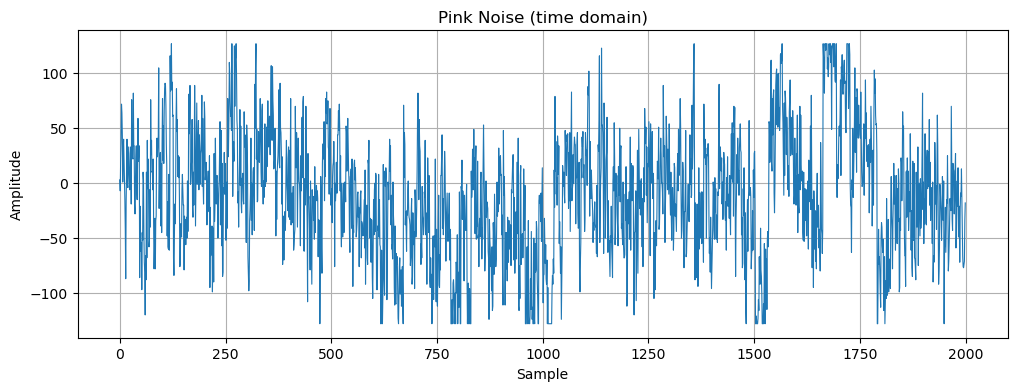

In [2]:
# --- Time-domain plot ---
plt.figure(figsize=(12, 4))
plt.plot(samples[:2000], linewidth=0.8)
plt.title("Pink Noise (time domain)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

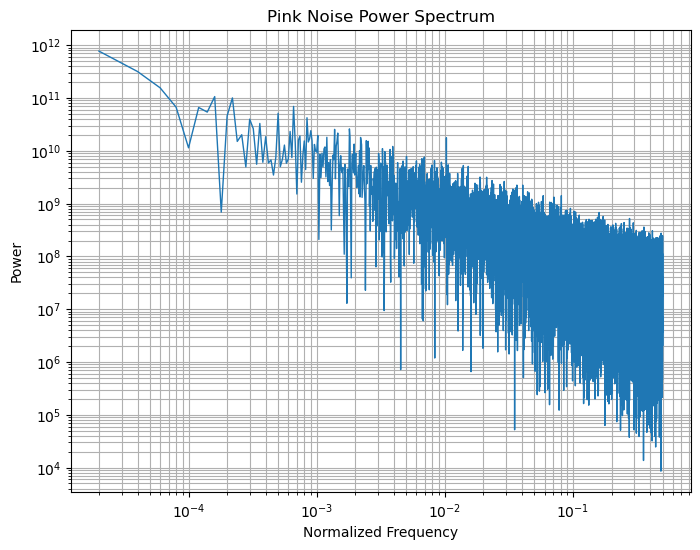

In [3]:
# --- Frequency-domain plot ---
# FFT-based PSD estimate
fft_vals = np.fft.rfft(samples)
power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(N, d=1.0)  # normalized frequency since no sample rate specified

# Skip DC bin for log plotting
freqs = freqs[1:]
power = power[1:]

plt.figure(figsize=(8, 6))
plt.loglog(freqs, power, linewidth=1.0)
plt.title("Pink Noise Power Spectrum")
plt.xlabel("Normalized Frequency")
plt.ylabel("Power")
plt.grid(True, which="both")
plt.show()

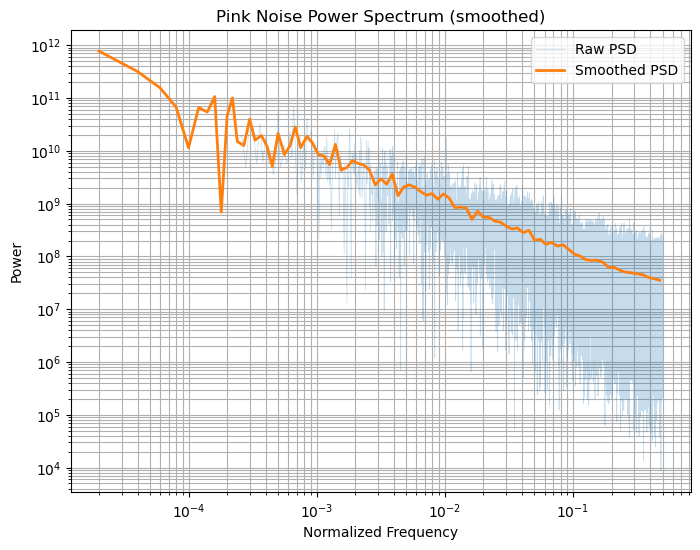

In [4]:
# Simple log-binning for a cleaner spectrum
num_bins = 100
bins = np.logspace(np.log10(freqs[0]), np.log10(freqs[-1]), num_bins)
digitized = np.digitize(freqs, bins)

bin_freqs = []
bin_power = []

for i in range(1, len(bins)):
    mask = digitized == i
    if np.any(mask):
        bin_freqs.append(freqs[mask].mean())
        bin_power.append(power[mask].mean())

bin_freqs = np.array(bin_freqs)
bin_power = np.array(bin_power)

plt.figure(figsize=(8, 6))
plt.loglog(freqs, power, alpha=0.25, linewidth=0.5, label="Raw PSD")
plt.loglog(bin_freqs, bin_power, linewidth=2, label="Smoothed PSD")
plt.title("Pink Noise Power Spectrum (smoothed)")
plt.xlabel("Normalized Frequency")
plt.ylabel("Power")
plt.grid(True, which="both")
plt.legend()
plt.show()